In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl

In [3]:
db = pd.read_csv('carros_eletricos_corrigidos.csv')

In [4]:
db.head()

,Modelo,Fabricante,Quantidade,MarketShare
0,SONG PLUS GS DM,BYD,25577,"5,3"
1,XRX HYBRID,TOYOTA,22360,"4,6"
2,BYD DOLPHIN MINI GS5EV,BYD,17516,"3,6"
3,DOLPHIN GS 180EV,BYD,17467,"3,6"
4,CCROSS XRX HYBRID,TOYOTA,17344,"3,6"


In [5]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Modelo       1008 non-null   object
 1   Fabricante   1009 non-null   object
 2   Quantidade   1009 non-null   int64 
 3   MarketShare  1009 non-null   object
dtypes: int64(1), object(3)
memory usage: 31.7+ KB


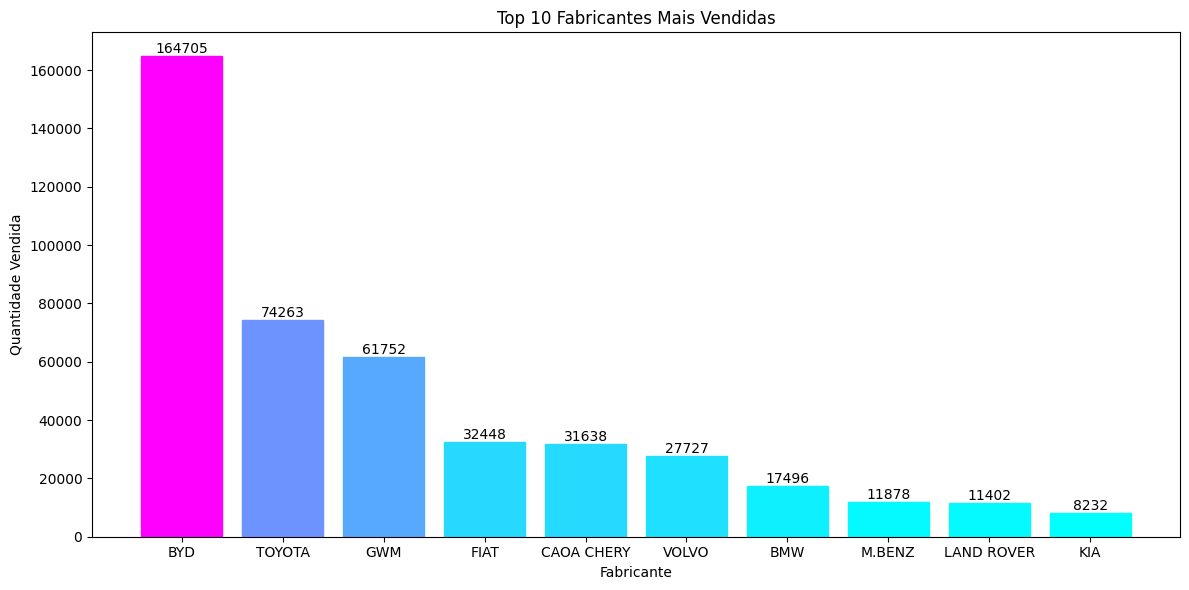

In [6]:
# Agrupando por fabricante e somando a quantidade
manufacturer_sales = db.groupby('Fabricante')['Quantidade'].sum()

# Classificando por quantidade em ordem decrescente
top_selling_manufacturers = manufacturer_sales.sort_values(ascending=False)

# Selecionando os 10 fabricantes mais vendidos para o gráfico
top_10_manufacturers = top_selling_manufacturers.head(10)

# Criando um gráfico de barras para os 10 principais
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(top_10_manufacturers.index, top_10_manufacturers.values)

# Criando um mapa de cores e normalizando os dados para a barra de cores
cmap = mpl.cm.cool
norm = mpl.colors.Normalize(vmin=top_10_manufacturers.values.min(), vmax=top_10_manufacturers.values.max())

# Adicionando cor às barras com base no mapa de cores
for i, bar in enumerate(bars):
    bar.set_color(cmap(norm(top_10_manufacturers.values[i])))

# Adicionando valores nas barras
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

ax.set_title('Top 10 Fabricantes Mais Vendidas')
ax.set_xlabel('Fabricante')
ax.set_ylabel('Quantidade Vendida')
#plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [8]:
# Mostrando as fabricantes
fabricantes = db['Fabricante'].unique()
print("Fabricantes:")
display(fabricantes)

Fabricantes:


array(['BYD', 'TOYOTA', 'FIAT', 'GWM', 'CAOA CHERY', 'VOLVO', 'BMW',
       'KIA', 'HONDA', 'JAC', 'AUDI', 'RENAULT', 'M.BENZ', 'LAND ROVER',
       'PORSCHE', 'MINI', 'LEXUS', 'GAC', 'HYUNDAI', 'PEUGEOT', 'JEEP',
       'MITSUBISHI', 'NISSAN', 'FORD', 'GM', 'CITROEN', 'OMODA', 'SUBARU',
       'ZEEKR', 'FOTON', 'JAGUAR', 'VW', 'NETA', 'HITECH', 'FEVER',
       'MASERATI', 'TESLA', 'CHRYSLER', 'LAMBORGHINI', 'BENTLEY', 'SERES',
       'DONGFENG', 'KEYTON', 'CADILLAC', 'DFSK', 'DENZA', 'MCLAREN',
       'RIVIAN', 'BAIC', 'SMART', 'LINCOLN', 'SINOGOLD', 'ROLLS ROYCE',
       'FERRARI', 'RDK', 'IVECO', 'MG'], dtype=object)

In [11]:
# Mostrando os modelos
modelos = db['Modelo'].unique()
print("Modelos:")
display(modelos)

Modelos:


array(['SONG PLUS GS DM', 'XRX HYBRID', 'BYD DOLPHIN MINI GS5EV', ...,
       'GWM HAVAL H6 TOP10', 'CHANGAN S7', 'E-TRON QUATTRO'], dtype=object)

In [12]:
vendas_ano = pd.read_csv('monitoramento_vendas.csv')

In [13]:
vendas_ano.head()

,ano,janeiro,fevereiro,março,abril,maio,junho,julho,agosto,setembro,outubro,novembro,dezembro,Total
0,2012,9,16,7,3,13,23,5,3,2.0,2.0,18.0,16.0,117
1,2013,45,22,53,50,12,29,65,45,23.0,39.0,52.0,56.0,491
2,2014,93,61,65,53,94,52,61,79,71.0,53.0,87.0,86.0,855
3,2015,72,56,61,73,72,74,74,100,82.0,55.0,65.0,62.0,846
4,2016,58,64,60,137,41,91,48,59,79.0,93.0,159.0,202.0,1091


In [14]:
vendas_ano.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ano        14 non-null     int64  
 1   janeiro    14 non-null     int64  
 2   fevereiro  14 non-null     int64  
 3   março      14 non-null     int64  
 4   abril      14 non-null     int64  
 5   maio       14 non-null     int64  
 6   junho      14 non-null     int64  
 7   julho      14 non-null     int64  
 8   agosto     14 non-null     int64  
 9   setembro   13 non-null     float64
 10  outubro    13 non-null     float64
 11  novembro   13 non-null     float64
 12  dezembro   13 non-null     float64
 13  Total      14 non-null     int64  
dtypes: float64(4), int64(10)
memory usage: 1.7 KB


In [15]:
# Removendo a linha de 2025 que ainda não está completa para não confundir no gráfico
vendas_ano = vendas_ano.drop(vendas_ano.index[-1])

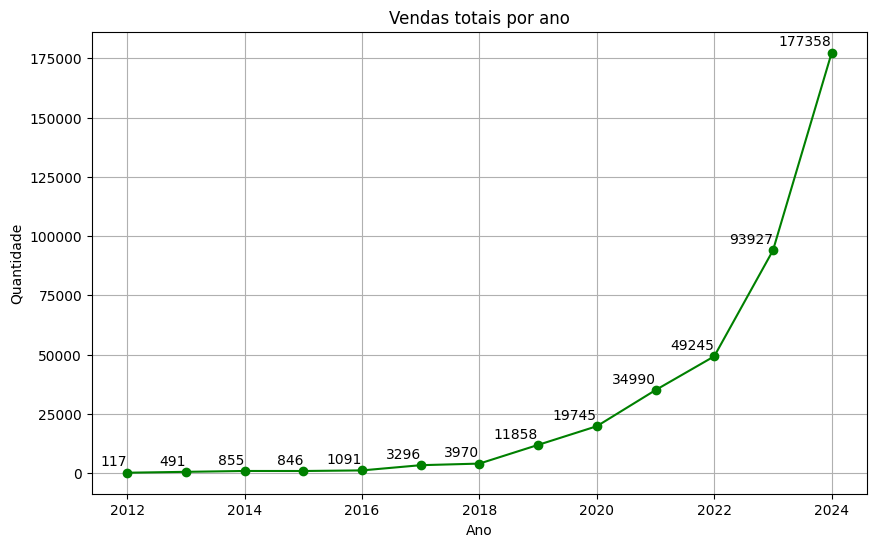

In [16]:
x = vendas_ano['ano']
y = vendas_ano['Total']
plt.figure(figsize=(10, 6)) # Increase figure size
plt.grid(True)
plt.title('Vendas totais por ano')
plt.xlabel('Ano')
plt.ylabel('Quantidade')
plt.plot(x, y, marker='o', color='green')

# Adicionando o número de vendas em cada ano
for i, txt in enumerate(y):
    plt.annotate(txt, (x[i], y[i]), textcoords="offset points", xytext=(0,5), ha='right')

plt.show()

## Top 10 modelos mais vendidos


In [17]:
# Selecionando modelo e quantidade vendida
modelo_vendas = db.groupby('Modelo')['Quantidade'].sum()

# Definindo a quantidade do maior para o menor
top_vendas_modelos = modelo_vendas.sort_values(ascending=False)

# Selecionando o top 10 modelos de vendas
top_10_modelos = top_vendas_modelos.head(10)

# Display the top 10 models
print("Top 10 Modelos Mais Vendidos:")
display(top_10_modelos)

Top 10 Modelos Mais Vendidos:


,Quantidade
Modelo,
SONG PLUS GS DM,25577
XRX HYBRID,22360
BYD DOLPHIN MINI GS5EV,17516
DOLPHIN GS 180EV,17467
CCROSS XRX HYBRID,17344
DOLPHIN MINI GS EV,13656
BYD SONG PRO GS DM,13374
FASTBACK AUDACE HYB,11687
HAVAL H6 PREM HEV,11267


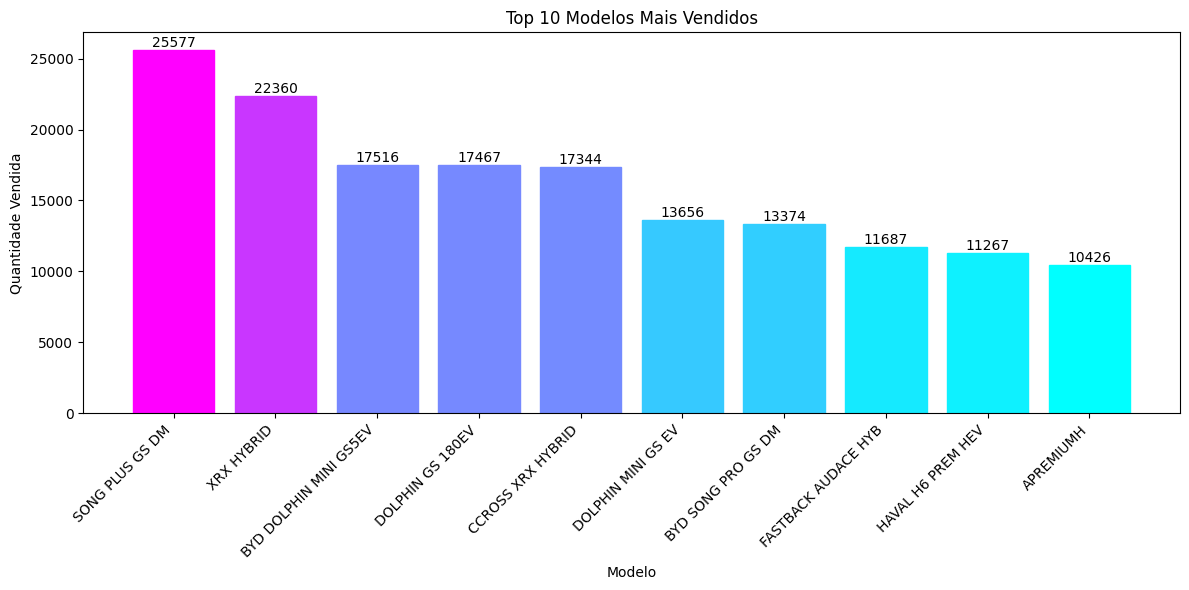

In [18]:
# Criando um gráfico em barras com o top 10 modelos mais vendidos
fig, ax = plt.subplots(figsize=(12, 6)) # Create figure and axes objects
bars = ax.bar(top_10_modelos.index, top_10_modelos.values)

# Colocando cor no gráfico
cmap = mpl.cm.cool
norm = mpl.colors.Normalize(vmin=top_10_modelos.values.min(), vmax=top_10_modelos.values.max())

for i, bar in enumerate(bars):
    bar.set_color(cmap(norm(top_10_modelos.values[i])))

# Adicionando valores nas barras
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

ax.set_title('Top 10 Modelos Mais Vendidos')
ax.set_xlabel('Modelo')
ax.set_ylabel('Quantidade Vendida')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()